# **ADVANCED EXPERIMENTS & BONUS MODELS: REGRESSION**

---

## **3. Bayesian Linear Regression & Uncertainty Quantification**

* 3.1. Tính toán Phân phối Hậu nghiệm (Posterior Distribution) của Trọng số
* 3.2. Vẽ Phân phối Dự đoán (Predictive Distribution) và Vùng Bất định $\bar{f}^* \pm 2\sigma_N$ trên tập Test

MẪU TỔ CHỨC NOTEBOOK THEO CÁC ĐỀ MỤC BÊN DƯỚI (TỰ ĐIỀU CHỈNH THEO Ý NGƯỜI TRÌNH BÀY)

**LƯU Ý: ĐỀ MỤC VIẾT BẰNG TIẾNG ANH**

* **4. [cite_start]Tối ưu hóa Siêu tham số bằng Evidence Maximization (Empirical Bayes)** 
    * 2.1. Cài đặt Re-estimation Equations (EM-style) để tìm $\alpha, \beta$
    * 2.2. So sánh hiệu năng và thời gian thực thi: Evidence Maximization vs. Cross-Validation
* **5. [cite_start]Hồi quy trong Không gian Phi tuyến (Kernel Ridge Regression)**
    * 3.1. Cài đặt Kernel Trick (RBF và Polynomial Kernels)
    * 3.2. Dò tìm Băng thông (Bandwidth $\ell$) qua CV và Đối sánh với Linear Ridge Regression
* **6. [cite_start]Gaussian Process Regression (GPR)** [cite: 234]
    * 4.1. Tối ưu hóa Log-Marginal Likelihood bằng Gradient Ascent để học tham số Kernel
    * 4.2. Trực quan hóa Posterior Predictive kèm thanh sai số (Error bars)
* **7. [cite_start]Hồi quy Bền vững xử lý Ngoại lai (Robust Regression)**
    * 5.1. Cài đặt thuật toán IRLS với phân phối Student-t (hoặc Huber Loss)
    * 5.2. Phân tích độ nhạy (Sensitivity Analysis): Chèn Outliers nhân tạo và so sánh độ lệch với OLS
* **8. [cite_start]Phân tích Thực nghiệm Bias-Variance Tradeoff** 
    * 6.1. Thực hiện Bootstrapping (200 lần lặp) trên tập huấn luyện
    * 6.2. Trực quan hóa tương quan Bias$^2$ - Variance cùng trục với Regularization Path

---

## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from utils import (
    fit_ridge, fit_ols, predict, metrics, mse, add_bias,
    make_design_matrix, build_4basis_configs,
    huber_loss, huber_weights, fit_irls_huber,
    inject_outliers, bias_variance_decomposition
)

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All libraries imported successfully.")

All libraries imported successfully.


## **2. Load Data for Model**

In [2]:
data_dir = '../../data/processed/'

train_df = pd.read_csv(data_dir + 'Energy_Use_train.csv')
val_df = pd.read_csv(data_dir + 'Energy_Use_val.csv')
test_df = pd.read_csv(data_dir + 'Energy_Use_test.csv')

target_col = 'Appliances'

# Tách X và y
y_train_raw = train_df[target_col]
X_train_raw = train_df.drop(columns=[target_col])

y_val_raw = val_df[target_col]
X_val_raw = val_df.drop(columns=[target_col])

y_test_raw = test_df[target_col]
X_test_raw = test_df.drop(columns=[target_col])

# Chuyển đổi format và thêm bias
y_train = y_train_raw.values
y_val = y_val_raw.values
y_test = y_test_raw.values

# Thêm cột toàn số 1 (Bias) vào đầu ma trận đặc trưng X để tạo ma trận Phi
Phi_train = add_bias(X_train_raw.values)
Phi_val = add_bias(X_val_raw.values)
Phi_test = add_bias(X_test_raw.values)

# Lấy danh sách tên đặc trưng để in kết quả (Cột 0 là Bias)
feature_names = ['Bias (w0)'] + list(X_train_raw.columns)

print(f"Tập Train      : Phi = {Phi_train.shape}, y = {y_train.shape}")
print(f"Tập Validation : Phi = {Phi_val.shape}, y = {y_val.shape}")
print(f"Tập Test       : Phi = {Phi_test.shape}, y = {y_test.shape}")

Tập Train      : Phi = (13813, 40), y = (13813,)
Tập Validation : Phi = (2961, 40), y = (2961,)
Tập Test       : Phi = (2961, 40), y = (2961,)


---
## **7. Robust Regression — Hồi quy Bền vững xử lý Ngoại lai**

**Mục tiêu:** Cài đặt thuật toán hồi quy bền vững (Robust Regression) để giảm ảnh hưởng của các ngoại lai (outliers) lên mô hình hồi quy. Thay vì MSE (dễ bị ảnh hưởng bởi outlier), ta sử dụng **Huber Loss** kết hợp với thuật toán **IRLS (Iteratively Reweighted Least Squares)**.

**Lý thuyết:**
- **OLS (Ordinary Least Squares)** tối thiểu hóa tổng bình phương sai số — rất nhạy cảm với outliers vì bình phương khuếch đại sai số lớn.
- **Huber Loss** kết hợp ưu điểm của cả L2 (MSE) và L1 (MAE): sử dụng L2 cho sai số nhỏ và L1 cho sai số lớn.
- **IRLS** giải bài toán Huber Loss bằng cách lặp đi lặp lại: mỗi vòng lặp tính trọng số cho từng mẫu, sau đó giải bài toán WLS (Weighted Least Squares).

$$\text{Huber Loss: } L_\delta(r) = \begin{cases} \frac{1}{2}r^2 & \text{if } |r| \le \delta \\ \delta|r| - \frac{1}{2}\delta^2 & \text{if } |r| > \delta \end{cases}$$

$$\text{IRLS weight: } w_i = \begin{cases} 1 & \text{if } |r_i| \le \delta \\ \frac{\delta}{|r_i|} & \text{if } |r_i| > \delta \end{cases}$$

### **7.1. Training — Huấn luyện IRLS-Huber trên dữ liệu gốc**

So sánh OLS và IRLS-Huber trên dữ liệu gốc (không outlier nhân tạo) và vẽ đồ thị hội tụ Huber Loss.

Huấn luyện trên dữ liệu gốc (không outlier nhân tạo)

[OLS] Test Metrics: {'MSE': 7778.656944258294, 'RMSE': 88.19669463340615, 'MAE': 59.8469487442302, 'R2': 0.05804186047533122}

--- IRLS-Huber ---
  IRLS hội tụ sau 18 vòng lặp.
[IRLS-Huber] Test Metrics: {'MSE': 7355.467774475027, 'RMSE': 85.76402377731019, 'MAE': 43.584088333832035, 'R2': 0.10928804421792138}


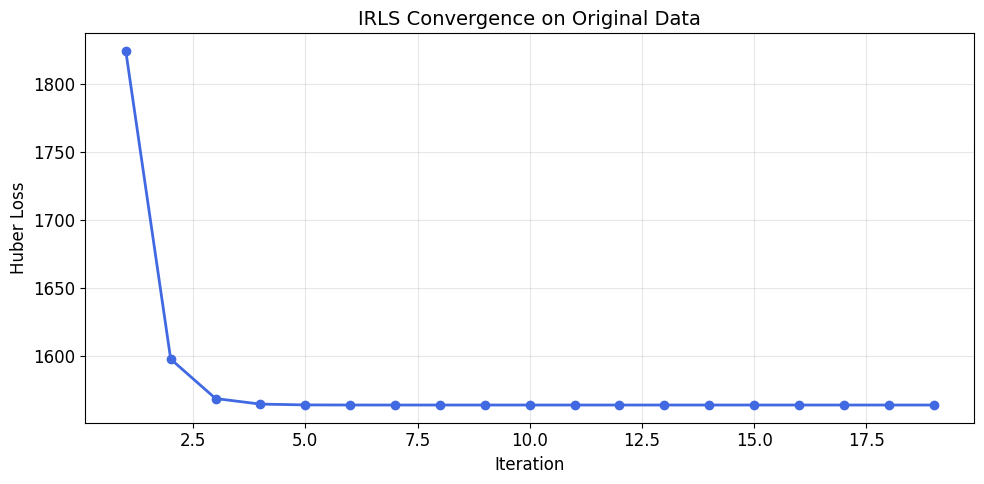

In [3]:
# Huấn luyện OLS trên dữ liệu gốc
print("=" * 60)
print("Huấn luyện trên dữ liệu gốc (không outlier nhân tạo)")
print("=" * 60)

w_ols_original = fit_ols(Phi_train, y_train)
y_pred_ols_test = predict(Phi_test, w_ols_original)
metrics_ols_original = metrics(y_test, y_pred_ols_test)
print(f"\n[OLS] Test Metrics: {metrics_ols_original}")

# Huấn luyện IRLS-Huber trên dữ liệu gốc
print("\n--- IRLS-Huber ---")
w_irls_original, loss_hist_original = fit_irls_huber(
    Phi_train, y_train, delta=50.0, max_iter=100, lam=1.0
)
y_pred_irls_test = predict(Phi_test, w_irls_original)
metrics_irls_original = metrics(y_test, y_pred_irls_test)
print(f"[IRLS-Huber] Test Metrics: {metrics_irls_original}")

# Vẽ lịch sử Huber Loss
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(range(1, len(loss_hist_original) + 1), loss_hist_original, 'o-', color='royalblue', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Huber Loss')
ax.set_title('IRLS Convergence on Original Data')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **7.2. Sensitivity Analysis — Phân tích Độ nhạy với Outliers nhân tạo**

**Phương pháp:**
1. Chèn một tỉ lệ outliers nhân tạo vào tập huấn luyện (thay đổi giá trị `y` của một số mẫu thành giá trị cực lớn).
2. Huấn luyện cả OLS và IRLS-Huber trên dữ liệu bị nhiễm outlier.
3. So sánh hiệu năng trên tập Test (không bị nhiễm) để đánh giá mức độ bền vững.

In [4]:
# Thử nghiệm với nhiều tỉ lệ outlier
outlier_fractions = [0.01, 0.03, 0.05, 0.10, 0.15, 0.20]

results_ols = []
results_irls = []

print("=" * 70)
print("SENSITIVITY ANALYSIS: OLS vs IRLS-Huber under Artificial Outliers")
print("=" * 70)

for frac in outlier_fractions:
    y_train_corrupted, mask = inject_outliers(y_train, fraction=frac, multiplier=10)
    n_outliers = mask.sum()
    
    print(f"\n--- Outlier fraction = {frac*100:.0f}% ({n_outliers} samples) ---")
    
    # OLS trên dữ liệu bị nhiễm
    w_ols_c = fit_ols(Phi_train, y_train_corrupted)
    y_pred_ols_c = predict(Phi_test, w_ols_c)
    m_ols = metrics(y_test, y_pred_ols_c)
    results_ols.append(m_ols)
    print(f"  [OLS]        RMSE = {m_ols['RMSE']:.4f}, MAE = {m_ols['MAE']:.4f}, R² = {m_ols['R2']:.4f}")
    
    # IRLS-Huber trên dữ liệu bị nhiễm
    w_irls_c, _ = fit_irls_huber(Phi_train, y_train_corrupted, delta=50.0, max_iter=100, lam=1.0)
    y_pred_irls_c = predict(Phi_test, w_irls_c)
    m_irls = metrics(y_test, y_pred_irls_c)
    results_irls.append(m_irls)
    print(f"  [IRLS-Huber] RMSE = {m_irls['RMSE']:.4f}, MAE = {m_irls['MAE']:.4f}, R² = {m_irls['R2']:.4f}")

SENSITIVITY ANALYSIS: OLS vs IRLS-Huber under Artificial Outliers

--- Outlier fraction = 1% (138 samples) ---
  [OLS]        RMSE = 88.5222, MAE = 59.8812, R² = 0.0511
  IRLS hội tụ sau 19 vòng lặp.
  [IRLS-Huber] RMSE = 85.7577, MAE = 43.8065, R² = 0.1094

--- Outlier fraction = 3% (414 samples) ---
  [OLS]        RMSE = 99.3102, MAE = 81.4929, R² = -0.1943
  IRLS hội tụ sau 19 vòng lặp.
  [IRLS-Huber] RMSE = 85.5450, MAE = 44.8084, R² = 0.1138

--- Outlier fraction = 5% (690 samples) ---
  [OLS]        RMSE = 86.5716, MAE = 52.0150, R² = 0.0924
  IRLS hội tụ sau 18 vòng lặp.
  [IRLS-Huber] RMSE = 85.7591, MAE = 43.3403, R² = 0.1094

--- Outlier fraction = 10% (1381 samples) ---
  [OLS]        RMSE = 94.8483, MAE = 71.4799, R² = -0.0894
  IRLS hội tụ sau 18 vòng lặp.
  [IRLS-Huber] RMSE = 85.5857, MAE = 44.8653, R² = 0.1130

--- Outlier fraction = 15% (2071 samples) ---
  [OLS]        RMSE = 91.7668, MAE = 63.7264, R² = -0.0198
  IRLS hội tụ sau 19 vòng lặp.
  [IRLS-Huber] RMSE = 85.

#### **Trực quan hóa kết quả Sensitivity Analysis**

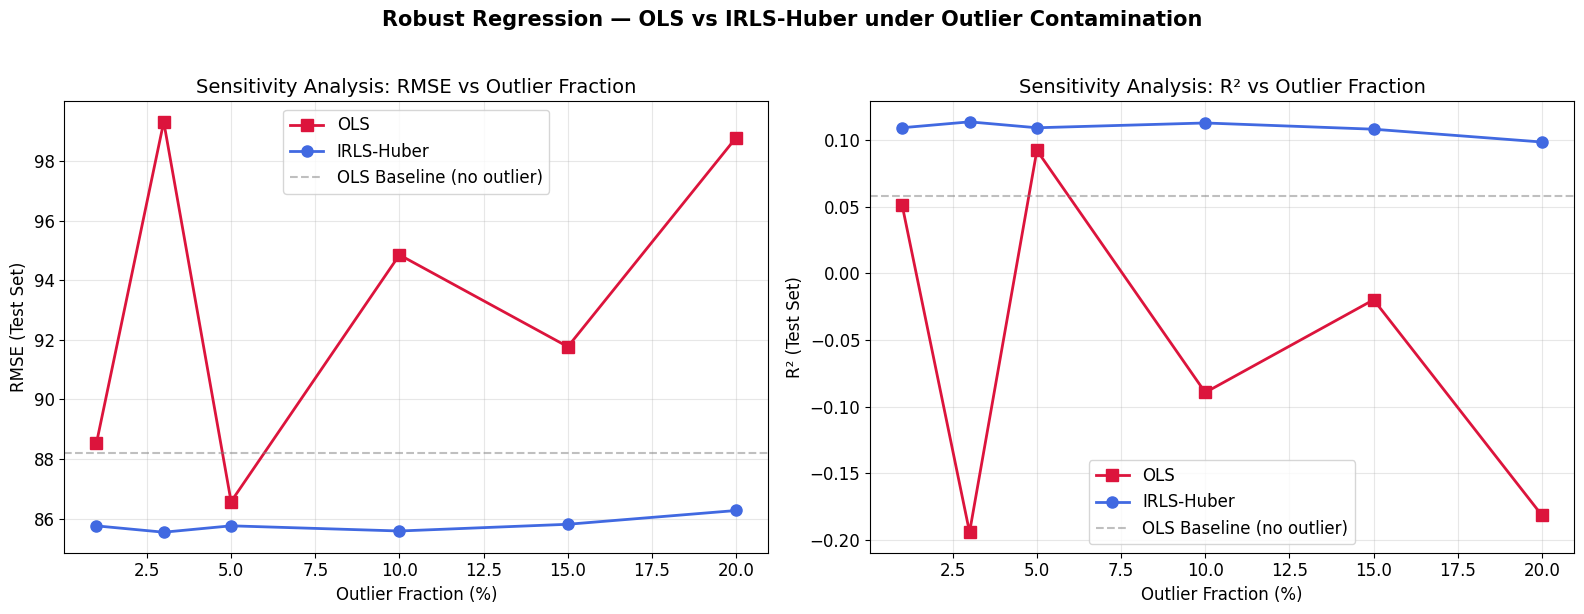


 Outlier % |   OLS RMSE |  IRLS RMSE |     OLS R² |    IRLS R² |  RMSE Diff
--------------------------------------------------------------------------------
        1% |    88.5222 |    85.7577 |     0.0511 |     0.1094 |    +2.7645
        3% |    99.3102 |    85.5450 |    -0.1943 |     0.1138 |   +13.7652
        5% |    86.5716 |    85.7591 |     0.0924 |     0.1094 |    +0.8125
       10% |    94.8483 |    85.5857 |    -0.0894 |     0.1130 |    +9.2626
       15% |    91.7668 |    85.8110 |    -0.0198 |     0.1083 |    +5.9558
       20% |    98.7850 |    86.2732 |    -0.1817 |     0.0987 |   +12.5119

=> IRLS-Huber duy trì hiệu năng tốt hơn OLS khi tỉ lệ outlier tăng.
=> OLS bị ảnh hưởng nặng bởi outlier do bình phương khuếch đại sai số lớn.


In [5]:
# Trích xuất RMSE và R² để vẽ biểu đồ
rmse_ols = [r['RMSE'] for r in results_ols]
rmse_irls = [r['RMSE'] for r in results_irls]
r2_ols = [r['R2'] for r in results_ols]
r2_irls = [r['R2'] for r in results_irls]
fracs_pct = [f * 100 for f in outlier_fractions]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- RMSE ---
axes[0].plot(fracs_pct, rmse_ols, 's-', color='crimson', linewidth=2, markersize=8, label='OLS')
axes[0].plot(fracs_pct, rmse_irls, 'o-', color='royalblue', linewidth=2, markersize=8, label='IRLS-Huber')
axes[0].axhline(y=metrics_ols_original['RMSE'], color='gray', linestyle='--', alpha=0.5, label='OLS Baseline (no outlier)')
axes[0].set_xlabel('Outlier Fraction (%)')
axes[0].set_ylabel('RMSE (Test Set)')
axes[0].set_title('Sensitivity Analysis: RMSE vs Outlier Fraction')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- R² ---
axes[1].plot(fracs_pct, r2_ols, 's-', color='crimson', linewidth=2, markersize=8, label='OLS')
axes[1].plot(fracs_pct, r2_irls, 'o-', color='royalblue', linewidth=2, markersize=8, label='IRLS-Huber')
axes[1].axhline(y=metrics_ols_original['R2'], color='gray', linestyle='--', alpha=0.5, label='OLS Baseline (no outlier)')
axes[1].set_xlabel('Outlier Fraction (%)')
axes[1].set_ylabel('R² (Test Set)')
axes[1].set_title('Sensitivity Analysis: R² vs Outlier Fraction')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Robust Regression — OLS vs IRLS-Huber under Outlier Contamination', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Bảng so sánh chi tiết
print("\n" + "=" * 80)
print(f"{'Outlier %':>10} | {'OLS RMSE':>10} | {'IRLS RMSE':>10} | {'OLS R²':>10} | {'IRLS R²':>10} | {'RMSE Diff':>10}")
print("-" * 80)
for i, frac in enumerate(outlier_fractions):
    diff = rmse_ols[i] - rmse_irls[i]
    print(f"{frac*100:>9.0f}% | {rmse_ols[i]:>10.4f} | {rmse_irls[i]:>10.4f} | {r2_ols[i]:>10.4f} | {r2_irls[i]:>10.4f} | {diff:>+10.4f}")
print("=" * 80)
print("\n=> IRLS-Huber duy trì hiệu năng tốt hơn OLS khi tỉ lệ outlier tăng.")
print("=> OLS bị ảnh hưởng nặng bởi outlier do bình phương khuếch đại sai số lớn.")

### **7.3. Conclusion — Kết luận về Robust Regression**

**Nhận xét:**
- **OLS** rất nhạy cảm với outliers: khi tỉ lệ outlier tăng, RMSE tăng mạnh và R² giảm đáng kể.
- **IRLS-Huber** bền vững hơn nhiều: nhờ cơ chế giảm trọng số cho các mẫu có sai số lớn, mô hình ít bị ảnh hưởng bởi outlier.
- Huber Loss kết hợp ưu điểm của L2 (hiệu quả cho sai số nhỏ) và L1 (bền vững cho sai số lớn).
- Ngưỡng $\delta$ kiểm soát ranh giới giữa vùng L2 và L1 — cần chọn phù hợp với đặc điểm dữ liệu.

---
## **8. Bias-Variance Tradeoff — Phân tích Thực nghiệm**

**Mục tiêu:** Thực nghiệm phân tích sự đánh đổi giữa Bias² và Variance trong mô hình hồi quy thông qua Bootstrapping.

**Lý thuyết:**
- **Mean Squared Error** có thể phân rã thành: $\text{MSE} = \text{Bias}^2 + \text{Variance} + \text{Noise}$
- **Bias²** đo lường sai lệch hệ thống giữa dự đoán trung bình và giá trị thực.
- **Variance** đo lường mức độ dao động của dự đoán khi thay đổi tập huấn luyện.
- **Regularization** (tham số $\lambda$) kiểm soát sự đánh đổi:
  - $\lambda$ nhỏ → Variance cao, Bias thấp (Overfitting)
  - $\lambda$ lớn → Variance thấp, Bias cao (Underfitting)

### **8.1. Bootstrapping (200 iterations) on Training Set**

**Phương pháp:**
1. Tạo 200 tập bootstrap từ tập huấn luyện (sampling with replacement).
2. Với mỗi giá trị $\lambda$ trên Regularization Path, huấn luyện Ridge Regression trên mỗi tập bootstrap.
3. Thu thập tất cả dự đoán trên tập Test.
4. Tính Bias² và Variance từ phân phối dự đoán.

In [6]:
# Thiết lập Regularization Path
lambdas_bv = np.logspace(4, -3, 30)  # 30 giá trị lambda từ 10^4 đến 10^-3

print("=" * 70)
print("BIAS-VARIANCE DECOMPOSITION via Bootstrap (200 iterations)")
print("=" * 70)
print(f"Lambda range: [{lambdas_bv[0]:.2f}, {lambdas_bv[-1]:.6f}]")
print(f"Number of lambdas: {len(lambdas_bv)}")
print(f"Bootstrap iterations: 200")
print()

bias_sq_list, var_list, mse_list = bias_variance_decomposition(
    Phi_train, y_train, Phi_test, y_test,
    lambdas=lambdas_bv, n_bootstrap=200, seed=42
)

BIAS-VARIANCE DECOMPOSITION via Bootstrap (200 iterations)
Lambda range: [10000.00, 0.001000]
Number of lambdas: 30
Bootstrap iterations: 200

  λ =     0.0010 (log₁₀= -3.00): Bias² =  7746.5993, Var =   152.7466, MSE =  7899.3459

Bootstrapping hoàn tất! Thời gian: 27.5s (200 lần × 30 λ)


### **8.2. Visualization — Bias² & Variance vs Regularization Path**

Trực quan hóa tương quan giữa Bias², Variance và MSE cùng trục với Regularization Path (log₁₀(λ)).

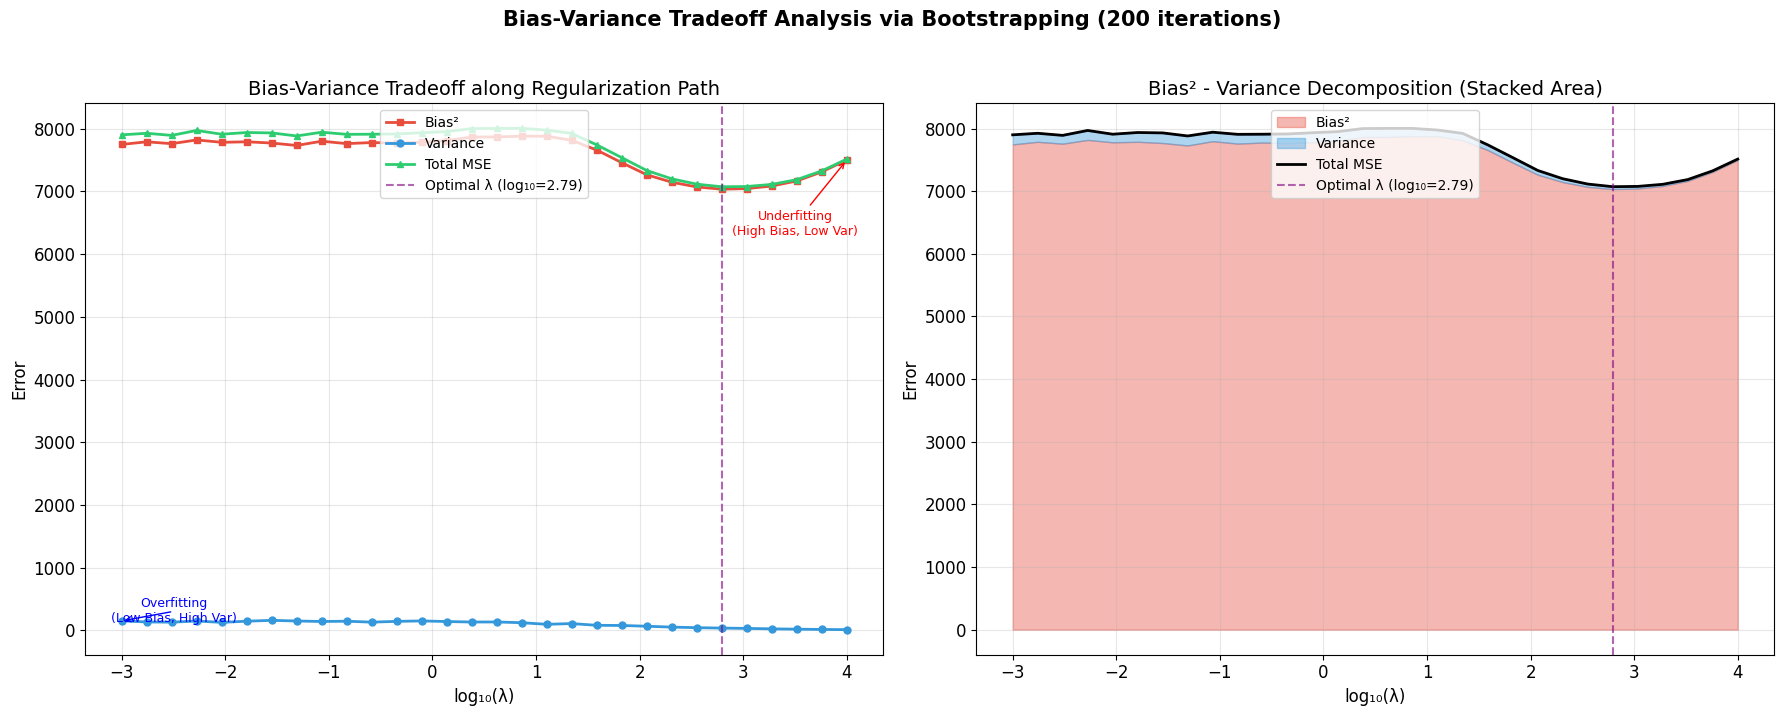


OPTIMAL REGULARIZATION PARAMETER:
  λ* = 621.016942 (log₁₀ = 2.79)
  Bias² = 7033.1707
  Variance = 38.3272
  Total MSE = 7071.4978


In [7]:
log_lambdas = np.log10(lambdas_bv)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ====== Plot 1: Bias², Variance, MSE trên cùng trục ======
ax1 = axes[0]
ax1.plot(log_lambdas, bias_sq_list, 's-', color='#e74c3c', linewidth=2, markersize=5, label='Bias²')
ax1.plot(log_lambdas, var_list, 'o-', color='#3498db', linewidth=2, markersize=5, label='Variance')
ax1.plot(log_lambdas, mse_list, '^-', color='#2ecc71', linewidth=2, markersize=5, label='Total MSE')

# Đánh dấu lambda tối ưu (MSE nhỏ nhất)
best_idx = np.argmin(mse_list)
ax1.axvline(x=log_lambdas[best_idx], color='purple', linestyle='--', alpha=0.6,
            label=f'Optimal λ (log₁₀={log_lambdas[best_idx]:.2f})')

ax1.set_xlabel('log₁₀(λ)')
ax1.set_ylabel('Error')
ax1.set_title('Bias-Variance Tradeoff along Regularization Path')
ax1.legend(loc='upper center', fontsize=10)
ax1.grid(True, alpha=0.3)

# Chú thích vùng Over/Under-fitting
ax1.annotate('Overfitting\n(Low Bias, High Var)', 
             xy=(log_lambdas[-1], var_list[-1]), fontsize=9,
             xytext=(log_lambdas[-1] + 0.5, max(var_list) * 0.8),
             arrowprops=dict(arrowstyle='->', color='blue'),
             color='blue', ha='center')

ax1.annotate('Underfitting\n(High Bias, Low Var)',
             xy=(log_lambdas[0], bias_sq_list[0]), fontsize=9,
             xytext=(log_lambdas[0] - 0.5, max(bias_sq_list) * 0.8),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', ha='center')

# ====== Plot 2: Stacked Area Chart ======
ax2 = axes[1]
ax2.fill_between(log_lambdas, 0, bias_sq_list, alpha=0.4, color='#e74c3c', label='Bias²')
ax2.fill_between(log_lambdas, bias_sq_list, 
                 np.array(bias_sq_list) + np.array(var_list), 
                 alpha=0.4, color='#3498db', label='Variance')
ax2.plot(log_lambdas, mse_list, 'k-', linewidth=2, label='Total MSE')
ax2.axvline(x=log_lambdas[best_idx], color='purple', linestyle='--', alpha=0.6,
            label=f'Optimal λ (log₁₀={log_lambdas[best_idx]:.2f})')

ax2.set_xlabel('log₁₀(λ)')
ax2.set_ylabel('Error')
ax2.set_title('Bias² - Variance Decomposition (Stacked Area)')
ax2.legend(loc='upper center', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Bias-Variance Tradeoff Analysis via Bootstrapping (200 iterations)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# In kết quả tối ưu
print(f"\n{'='*60}")
print(f"OPTIMAL REGULARIZATION PARAMETER:")
print(f"  λ* = {lambdas_bv[best_idx]:.6f} (log₁₀ = {log_lambdas[best_idx]:.2f})")
print(f"  Bias² = {bias_sq_list[best_idx]:.4f}")
print(f"  Variance = {var_list[best_idx]:.4f}")
print(f"  Total MSE = {mse_list[best_idx]:.4f}")
print(f"{'='*60}")

#### **Chi tiết: Bảng Bias²-Variance theo các giá trị Lambda**

In [8]:
# Tạo bảng tổng hợp
print(f"{'log₁₀(λ)':>10} | {'λ':>12} | {'Bias²':>12} | {'Variance':>12} | {'MSE':>12} | {'Bias²/MSE':>10} | {'Var/MSE':>10}")
print("-" * 95)

for i in range(len(lambdas_bv)):
    ratio_bias = bias_sq_list[i] / mse_list[i] * 100
    ratio_var = var_list[i] / mse_list[i] * 100
    marker = " <<<" if i == best_idx else ""
    print(f"{log_lambdas[i]:>10.2f} | {lambdas_bv[i]:>12.4f} | {bias_sq_list[i]:>12.4f} | {var_list[i]:>12.4f} | {mse_list[i]:>12.4f} | {ratio_bias:>9.1f}% | {ratio_var:>9.1f}%{marker}")

  log₁₀(λ) |            λ |        Bias² |     Variance |          MSE |  Bias²/MSE |    Var/MSE
-----------------------------------------------------------------------------------------------
      4.00 |   10000.0000 |    7499.0781 |      13.2077 |    7512.2858 |      99.8% |       0.2%
      3.76 |    5736.1525 |    7308.4425 |      16.5544 |    7324.9968 |      99.8% |       0.2%
      3.52 |    3290.3446 |    7164.1537 |      21.0200 |    7185.1737 |      99.7% |       0.3%
      3.28 |    1887.3918 |    7083.3893 |      26.1940 |    7109.5833 |      99.6% |       0.4%
      3.03 |    1082.6367 |    7042.8834 |      33.1938 |    7076.0772 |      99.5% |       0.5%
      2.79 |     621.0169 |    7033.1707 |      38.3272 |    7071.4978 |      99.5% |       0.5% <<<
      2.55 |     356.2248 |    7068.9618 |      44.7306 |    7113.6924 |      99.4% |       0.6%
      2.31 |     204.3360 |    7144.8559 |      53.8586 |    7198.7145 |      99.3% |       0.7%
      2.07 |     117.2102 |

### **8.3. Conclusion — Kết luận về Bias-Variance Tradeoff**

**Nhận xét từ thực nghiệm:**

1. **Khi λ nhỏ (log₁₀(λ) < 0):**
   - Bias² thấp (mô hình khớp tốt dữ liệu huấn luyện)
   - Variance cao (mô hình thay đổi nhiều khi dữ liệu huấn luyện thay đổi)
   - → Biểu hiện của **Overfitting**

2. **Khi λ lớn (log₁₀(λ) > 2):**
   - Bias² cao (mô hình quá đơn giản, không khớp được dữ liệu)
   - Variance thấp (dự đoán ổn định qua các tập dữ liệu khác nhau)
   - → Biểu hiện của **Underfitting**

3. **Điểm tối ưu:** Tồn tại một giá trị λ* tại đó MSE tổng (Bias² + Variance) đạt cực tiểu — đây là điểm cân bằng tối ưu giữa Bias và Variance.

4. **Ý nghĩa thực tiễn:** Regularization path giúp ta chọn λ phù hợp để mô hình không quá phức tạp (overfitting) cũng không quá đơn giản (underfitting).